# Initialiazation Packages

In [1]:
import numpy as np
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from dataclasses import dataclass

# -------------------------------------------------------------------
# Units:
# Use energies/frequencies in ANGULAR units.
# Convenient choice: time in ns, energies in rad/ns.
# Then 1 GHz corresponds to 2*pi rad/ns.
# -------------------------------------------------------------------
GHz = 2.0 * np.pi  # multiply a value in GHz by this

## Fluxonium Potential

$$
    U(\varphi)=\frac{E_L}{2}(\phi-\varphi_{\mathrm{ext}}(t))^2-E_J\cos\phi
$$

In [37]:
import sys
sys.path.append('../src')  # add the src directory to the Python path
from fluxonium_classical import FluxoniumParams, potential, find_potential_extrema

print("Defining parameters...")
param = FluxoniumParams(
    EC=1.0,
    EJ=8.5,
    EL=0.5,
    phi_ext0=0.,
    omega_d=2.0,
    A_charge=0.0,
    A_flux=0.0,
)
display(param)

Defining parameters...


FluxoniumParams(EC=1.0, EJ=8.5, EL=0.5, phi_ext0=0.0, omega_d=2.0, A_charge=0.0, A_flux=0.0)

In [38]:
print("Defining potential plotting function...")
def plot_fluxonium_potential(
    p: FluxoniumParams,
    phi_min=-4*np.pi,
    phi_max=4*np.pi,
    npoints=400,
    subtract_min=False,
    ax=None,
):
    """
    Plot the undriven fluxonium potential

        U(phi) = EL/2 * (phi - phi_ext)^2 - EJ cos(phi)

    Parameters
    ----------
    p : FluxoniumParams
        Fluxonium parameters
    phi_min, phi_max : float
        Range of phi to plot.
    npoints : int
        Number of grid points.
    subtract_min : bool
        If True, shift the potential so its minimum value is zero.
    ax : matplotlib axis or None
        If None, create a new figure.
    """
    phi = np.linspace(phi_min, phi_max, npoints)
    U = potential(phi, p)

    if subtract_min:
        U_min = np.min(U)
        U = U - U_min
        

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5))

    ax.plot(phi, U, lw=2)
    ax.set_xlabel(r'$\phi$')
    ax.set_ylabel(r'$U(\phi)$')
    ax.set_title('Undriven fluxonium potential')
    ax.grid(True, alpha=0.3)

    return phi, U, U_min, ax

Defining potential plotting function...


In [39]:
def plot_fluxonium_potential_with_extrema(
    p: FluxoniumParams,
    phi_min=-4*np.pi,
    phi_max=4*np.pi,
    npoints=4000,
    subtract_min=False,
    ):
    
    phi, U, U_min, ax = plot_fluxonium_potential(
        p,
        phi_min=phi_min,
        phi_max=phi_max,
        npoints=npoints,
        subtract_min=subtract_min,
    )

    minima, maxima = find_potential_extrema(p.EJ, p.EL, p.phi_ext0, phi_min, phi_max)

    def Ufun(x):
        val = 0.5 * p.EL * (x - p.phi_ext0)**2 - p.EJ * np.cos(x)
        if subtract_min:
            val -= U_min
        return val

    if len(minima) > 0:
        ax.plot(minima, [Ufun(x) for x in minima], 'o', label='minima')

    if len(maxima) > 0:
        ax.plot(maxima, [Ufun(x) for x in maxima], 's', label='maxima')

    ax.legend()
    return phi, U, minima, maxima, ax

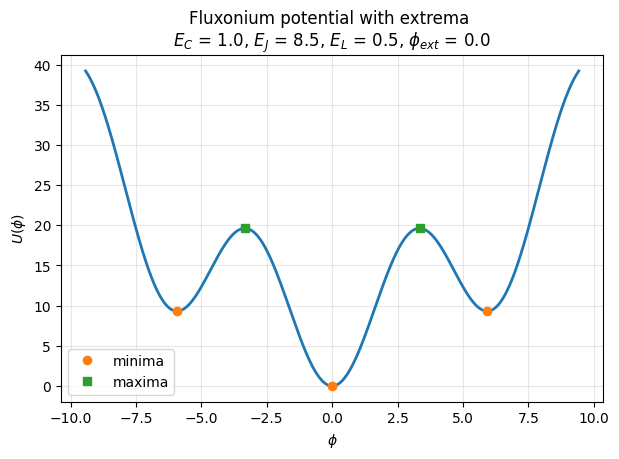

Minima phi: [-5.92705468e+00 -1.08420217e-19  5.92705468e+00]
Maxima phi: [-3.3393082  3.3393082]


In [50]:
phi, U, minima, maxima, ax = plot_fluxonium_potential_with_extrema(
    param,
    phi_min=-3*np.pi,
    phi_max=3*np.pi,
    npoints= 1000,
    subtract_min=True,
)
plt.title(f'Fluxonium potential with extrema \n' \
rf'$E_C$ = {param.EC}, $E_J$ = {param.EJ}, $E_L$ = {param.EL}, $\phi_{{ext}}$ = {param.phi_ext0}')
plt.show()


print("Minima phi:", minima)
print("Maxima phi:", maxima)

## Fluxonium Driven Stroboscopic Poincare

$$
    H(t)=4E_C n^2+\frac{E_L}{2}\bigl(\phi-\varphi_{\mathrm{ext}}(t)\bigr)^2-E_J\cos\phi
    +\varepsilon_n\cos(\omega_d t)\,n
$$

### Testing Solver accuracy

In [2]:
import sys
sys.path.append('../src')  # add the src directory to the Python path
from fluxonium_classical import FluxoniumParams, energy_balance_from_augmented_solution, make_initial_conditions


print("Defining parameters...")
param = FluxoniumParams(
    EC=1.0,
    EJ=8.5,
    EL=0.5,
    phi_ext0= 0.,
    omega_d=2.0,
    A_charge=0.01,
    A_flux=0.0,
)
display(param)

Defining parameters...


FluxoniumParams(EC=1.0, EJ=8.5, EL=0.5, phi_ext0=0.0, omega_d=2.0, A_charge=0.01, A_flux=0.0)

In [19]:
# Initial conditions:
from fluxonium_classical import solve_with_work

print("Generating initial conditions...")
ics = make_initial_conditions(
    phi_min=-3*np.pi,
    phi_max= 3*np.pi,
    n_min=-6.0,
    n_max= 6.0,
    n_phi=10,
    n_n=8,
    random=True,
    seed=4,
)

t_eval = np.linspace(0.0, 5000.0, 1000)

Generating initial conditions...


In [20]:
ics_sel = [0, 1]  
atol =[1e-6, 1e-8, 1e-10]
rtol =[1e-8, 1e-10, 1e-12]

for i in range(len(ics_sel)):
    for j in range(len(atol)):
        print(f"Testing initial condition {i} with atol={atol[j]}, rtol={rtol[j]}...")
        u0 = ics[ics_sel[i]]
        sol = solve_with_work(
            u0=u0,
            t_span=(0.0, t_eval[-1]),
            p=param,
            t_eval=t_eval,
            method="DOP853",
            rtol=rtol[j],
            atol=atol[j],
        )

        diag = energy_balance_from_augmented_solution(sol, param)

        print("max abs error =", diag["max_abs_error"])
        print("rms error     =", diag["rms_error"])


Testing initial condition 0 with atol=1e-06, rtol=1e-08...
max abs error = 0.6350381731493264
rms error     = 0.3751819853869219
Testing initial condition 0 with atol=1e-08, rtol=1e-10...
max abs error = 0.0020495127700378146
rms error     = 0.0011836280119031078
Testing initial condition 0 with atol=1e-10, rtol=1e-12...
max abs error = 4.774379407351814e-06
rms error     = 2.7512834633624688e-06
Testing initial condition 1 with atol=1e-06, rtol=1e-08...
max abs error = 0.13005709183136158
rms error     = 0.07334675431921078
Testing initial condition 1 with atol=1e-08, rtol=1e-10...
max abs error = 0.00012225940664442147
rms error     = 7.067330691776705e-05
Testing initial condition 1 with atol=1e-10, rtol=1e-12...
max abs error = 1.4846392310613682e-06
rms error     = 8.571027440116651e-07


In [18]:
import sys
sys.path.append('../src')  # add the src directory to the Python path
from fluxonium_classical import FluxoniumParams, poincare_section, make_initial_conditions

print("Defining parameters...")
param = FluxoniumParams(
    EC=1.0,
    EJ=8.5,
    EL=0.5,
    phi_ext0= 0.,
    omega_d=2.0,
    A_charge=0.01,
    A_flux=0.0,
)
display(param)

Defining parameters...


FluxoniumParams(EC=1.0, EJ=8.5, EL=0.5, phi_ext0=0.0, omega_d=2.0, A_charge=0.01, A_flux=0.0)

In [67]:
# Initial conditions:
ics = make_initial_conditions(
    phi_min=-3*np.pi,
    phi_max= 3*np.pi,
    n_min=-6.0,
    n_max= 6.0,
    n_phi=10,
    n_n=8,
    random=True,
    seed=4,
)

# Poincare section at phase_fraction = 0.0
points = poincare_section(
    p=param,
    initial_conditions=ics,
    n_discard=0,
    n_strobes=200,
    phase_fraction=0.0,      # use 1/8 if you want a shifted strobe phase
    wrap_phi_for_plot=False, # keep unwrapped to see interwell transport
    method = "DOP853",
    rtol = 1e-6,
    atol = 1e-6,
)


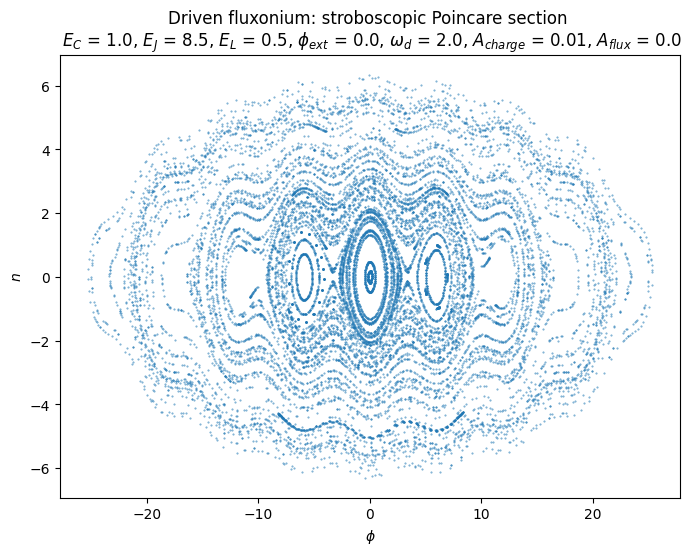

In [ ]:
plt.figure(figsize=(7.0, 5.2))
plt.scatter(points[:, 0], points[:, 1], s=0.2, alpha=0.7, rasterized=True)
plt.xlabel(r"$\phi$")
plt.ylabel(r"$n$")
plt.tight_layout()
plt.title("Driven fluxonium: stroboscopic Poincare section \n " \
""rf"$E_C$ = {param.EC}, $E_J$ = {param.EJ}, $E_L$ = {param.EL}, $\phi_{{ext}}$ = {param.phi_ext0}, " \
""rf"$\omega_d$ = {param.omega_d}, $A_{{charge}}$ = {param.A_charge}, $A_{{flux}}$ = {param.A_flux}")
plt.show()